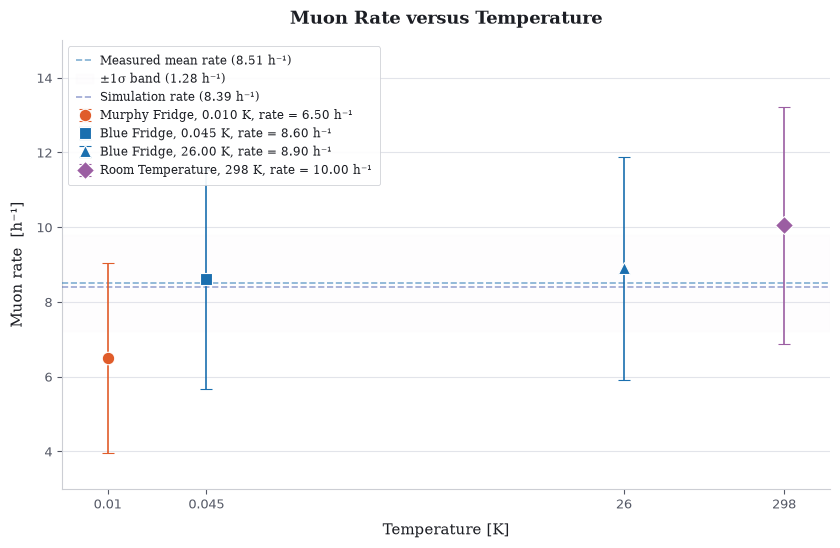

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ── Data ─────────────────────────────────────────────────────────────────────
# Each entry: (temperature K, rate muons/hr, source label)
data = [
    (0.010, 6.50, "Murphy Fridge, 0.010 K, rate = 6.50 h⁻¹"),
    (0.045, 8.60, "Blue Fridge, 0.045 K, rate = 8.60 h⁻¹"),
    (26,  8.90, "Blue Fridge, 26.00 K, rate = 8.90 h⁻¹"),
    (298,  10.05, "Room Temperature, 298 K, rate = 10.00 h⁻¹"),
]

# ── Aesthetic tokens ──────────────────────────────────────────────────────────
COLORS  = ["#e05c2a", "#1a6faf", "#1a6faf", "#9b5ea2"]
MARKERS = ["o", "s", "^", "D"]

fig_bg  = "#ffffff"
ax_bg = "#ffffff"
spine   = "#ccced4"
grid_c  = "#e2e4ea"
text_c  = "#1c1e24"
annot_c = "#555966"

# ── Figure setup ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8.5, 6))
fig.patch.set_facecolor(fig_bg)
ax.set_facecolor(ax_bg)

# ── Plot each point ───────────────────────────────────────────────────────────
for (temp, rate, label), color, marker in zip(data, COLORS, MARKERS):
    ax.errorbar(
        temp, rate,
        yerr=np.sqrt(rate),          # ← ±√rate error bar
        color=color, marker=marker, markersize=9, zorder=5,
        label=label,
        markeredgecolor="white", markeredgewidth=0.8,
        capsize=4, capthick=1.2, elinewidth=1.2, ecolor=color,
        linestyle="none",
    )

# ── Reference band: ±1σ around the mean rate ─────────────────────────────────
rates     = [d[1] for d in data]
mean_rate = np.mean(rates)
std_rate  = np.std(rates)
sim_rate = 8.39
ax.axhline(mean_rate, color="#1a6faf", linewidth=1.2, linestyle="--",
           alpha=0.55, zorder=3, label=f"Measured mean rate ({mean_rate:.2f} h⁻¹)")
ax.axhspan(mean_rate - std_rate, mean_rate + std_rate,
           color="#fae6fa", alpha=0.07, zorder=2,
           label=f"±1σ band ({std_rate:.2f} h⁻¹)")
ax.axhline(sim_rate, color="#4a5faf", linewidth=1.2, linestyle="--",
           alpha=0.55, zorder=3, label=f"Simulation rate ({sim_rate:.2f} h⁻¹)")


# ── Log x-axis ────────────────────────────────────────────────────────────────
ax.set_xscale("log")

temps = [d[0] for d in data]
ax.set_xticks(temps)
ax.get_xaxis().set_major_formatter(
    ticker.FuncFormatter(lambda v, _: f"{v:g}")
)
ax.tick_params(axis="x", which="minor", bottom=False)

# ── Axis limits ───────────────────────────────────────────────────────────────
ax.set_xlim(0.005, 600)
ax.set_ylim(3, 15)

# ── Grid ─────────────────────────────────────────────────────────────────────
ax.yaxis.grid(True, color=grid_c, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

# ── Spines ────────────────────────────────────────────────────────────────────
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
for s in ["bottom", "left"]:
    ax.spines[s].set_color(spine)
    ax.spines[s].set_linewidth(0.8)

# ── Labels ────────────────────────────────────────────────────────────────────
ax.set_xlabel("Temperature [K]", fontsize=11, color=text_c,
              labelpad=8, fontfamily="DejaVu Serif")
ax.set_ylabel("Muon rate  [h⁻¹]", fontsize=11, color=text_c,
              labelpad=8, fontfamily="DejaVu Serif")
ax.tick_params(colors=annot_c, labelsize=9.5)

# ── Title ─────────────────────────────────────────────────────────────────────
ax.set_title("Muon Rate versus Temperature",
             fontsize=13, fontweight="semibold", color=text_c,
             fontfamily="DejaVu Serif", pad=12, loc="center")

# fig.text(0.125, 0.91,
#          "Rate is consistent across five orders of magnitude in temperature",
#          fontsize=8.5, color=annot_c, fontfamily="DejaVu Serif", style="italic")

# ── Legend ────────────────────────────────────────────────────────────────────
legend = ax.legend(
    frameon=True, framealpha=0.92, edgecolor=spine,
    fontsize=8.5, loc="upper left",
    handlelength=1.4, handletextpad=0.6, borderpad=0.7, labelspacing=0.45,
)
legend.get_frame().set_linewidth(0.6)
for text in legend.get_texts():
    text.set_color(text_c)
    text.set_fontfamily("DejaVu Serif")

# ── Save / show ───────────────────────────────────────────────────────────────
fig.tight_layout(rect=[0, 0, 1, 0.93])
# fig.savefig("muon_rate_vs_temperature.png", dpi=300, bbox_inches="tight", facecolor=fig_bg)
plt.show()

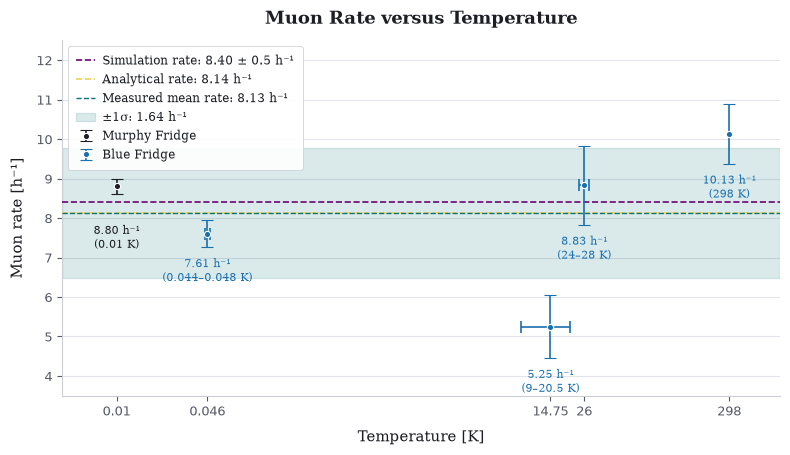

In [37]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import numpy as np

# ── Data ─────────────────────────────────────────────────────────────────────
data = [
    (0.01,  0.01,  0.01,   8.80,  0.2009775116, "Murphy Fridge"),
    (0.044, 0.048, 0.046,  7.607361963, 0.3415806358, "Blue Fridge"),
    (9,     20.5,  14.75,  5.250596659, 0.7915572292, "Blue Fridge"),
    (24,    28,    26,     8.833522084, 1.000199419,  "Blue Fridge"),
    (298,   298,   298,    10.1343785,  0.7532824214, "Blue Fridge"),
]

COLORS  = ["#1c1e24", "#1a6faf", "#1a6faf", "#1a6faf", "#1a6faf"]
MARKERS = [".", ".", ".", ".", "."]

fig_bg  = "#ffffff"
ax_bg = "#ffffff"
spine   = "#ccced4"
grid_c  = "#e2e4ea"
text_c  = "#1c1e24"
annot_c = "#555966"

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(fig_bg)
ax.set_facecolor(ax_bg)

# ── Plot data points (no label= so they stay out of the legend) ──────────────
for (t_low, t_high, avg_t, rate, unc, label), color, marker in zip(data, COLORS, MARKERS):
    if t_low == t_high:
        ax.errorbar(
            avg_t, rate, yerr=unc,
            color=color, marker=marker, markersize=9, zorder=5,
            markeredgecolor="white", markeredgewidth=0.8,
            capsize=4, capthick=1.2, elinewidth=1.2, ecolor=color,
            linestyle="none",
            label=label
        )
    else:
        # Vertical error bar
        ax.errorbar(
            avg_t, rate, yerr=unc,
            color=color, marker=marker, markersize=9, zorder=6,
            markeredgecolor="white", markeredgewidth=0.8,
            capsize=4, capthick=1.2, elinewidth=1.2, ecolor=color,
            linestyle="none",
        )
        # Horizontal T-range bar
        ax.errorbar(
            avg_t, rate,
            xerr=[[avg_t - t_low], [t_high - avg_t]],
            color=color, markersize=0, zorder=5,
            capsize=4, capthick=1.2, elinewidth=1.2, ecolor=color,
            linestyle="none",
        )
# ── Inline labels below each data point ──────────────────────────────────────
# (avg_t, x_offset_pts, y_offset_pts)
offsets = {
    0.01:   (0,    -20),
    0.046:  (0,    -6),
    14.75:  (0,   -6),
    26:     (0,    -6),
    298:    (0,   -6),   # nudge right so it doesn't overlap the error bar cap
}

for (t_low, t_high, avg_t, rate, unc, label), color in zip(data, COLORS):
    if t_low == t_high:
        temp_str = f"{t_low:g} K"
    else:
        temp_str = f"{t_low:g}–{t_high:g} K"

    annotation = f"{rate:.2f} h⁻¹\n({temp_str})"
    x_off, y_off = offsets[avg_t]

    ax.annotate(
        annotation,
        xy=(avg_t, rate - unc),
        xytext=(x_off, y_off),
        textcoords="offset points",
        ha="center", va="top",
        fontsize=8, color=color,
        fontfamily="DejaVu Serif",
        linespacing=1.3,
    )

# ── Reference lines (these are the only legend entries) ──────────────────────
rates        = [d[3] for d in data]
mean_rate    = np.mean(rates)
std_rate     = np.std(rates)
sim_rate     = 8.4
analytical_rate = 8.14 


ax.axhline(sim_rate, color="#6a0572", linewidth=1.2, linestyle="--",
           alpha=1.0, zorder=3, label=f"Simulation rate: {sim_rate:.2f} ± 0.5 h⁻¹")
ax.axhline(analytical_rate, color="#f0d060", linewidth=1.2, linestyle="--",
           alpha=1.0, zorder=3, label=f"Analytical rate: {analytical_rate:.2f} h⁻¹")
ax.axhline(mean_rate, color="#0a7373", linewidth=1.0, linestyle="--",
           alpha=1.0, zorder=3, label=f"Measured mean rate: {mean_rate:.2f} h⁻¹")
ax.axhspan(mean_rate - std_rate, mean_rate + std_rate,
           color="#0a7373", alpha=0.15, zorder=2,
           label=f"±1σ: {std_rate:.2f} h⁻¹")

# ── Log x-axis ────────────────────────────────────────────────────────────────
ax.set_xscale("log")

tick_vals = [0.01, 0.046, 14.75, 26, 298]
ax.set_xticks(tick_vals)
ax.get_xaxis().set_major_formatter(
    ticker.FuncFormatter(lambda v, _: f"{v:g}")
)
ax.tick_params(axis="x", which="minor", bottom=False)

ax.set_xlim(0.004, 700)
ax.set_ylim(3.5, 12.5)

# ── Grid, spines ─────────────────────────────────────────────────────────────
ax.yaxis.grid(True, color=grid_c, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
for s in ["bottom", "left"]:
    ax.spines[s].set_color(spine)
    ax.spines[s].set_linewidth(0.8)

# ── Axis labels ───────────────────────────────────────────────────────────────
ax.set_xlabel("Temperature [K]", fontsize=11, color=text_c,
              labelpad=8, fontfamily="DejaVu Serif")
ax.set_ylabel("Muon rate [h⁻¹]", fontsize=11, color=text_c,
              labelpad=8, fontfamily="DejaVu Serif")
ax.tick_params(colors=annot_c, labelsize=9.5)

ax.set_title("Muon Rate versus Temperature",
             fontsize=13, fontweight="semibold", color=text_c,
             fontfamily="DejaVu Serif", pad=12, loc="center")

# ── Legend (reference lines only) ────────────────────────────────────────────
legend = ax.legend(
    frameon=True, framealpha=0.92, edgecolor=spine,
    fontsize=8.5, loc="upper left",
    handlelength=1.6, handletextpad=0.6, borderpad=0.7, labelspacing=0.5,
)
legend.get_frame().set_linewidth(0.6) 
for text in legend.get_texts():
    text.set_color(text_c)
    text.set_fontfamily("DejaVu Serif")

# ── Save ──────────────────────────────────────────────────────────────────────
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig("muon_rate_vs_temperature.png", dpi=800, bbox_inches="tight", facecolor=fig_bg)
plt.show()

In [4]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np


def plot_waveforms(tekfile, lecfile1, lecfile2, save_dir=None, show=True):

    tek_time = np.loadtxt(tekfile, skiprows=17, usecols=0, delimiter=',', dtype=float)
    tek_ch1_voltages = np.loadtxt(tekfile, skiprows=17, usecols=1, delimiter=',', dtype=float)
    tek_ch2_voltages = np.loadtxt(tekfile, skiprows=17, usecols=2, delimiter=',', dtype=float)

    lec_time1 = np.loadtxt(lecfile1, skiprows=5, usecols=0, delimiter=',', dtype=float)
    lec_ch1_voltages = np.loadtxt(lecfile1, skiprows=5, usecols=1, delimiter=',', dtype=float)
    lec_time2 = np.loadtxt(lecfile2, skiprows=5, usecols=0, delimiter=',', dtype=float)
    lec_ch2_voltages = np.loadtxt(lecfile2, skiprows=5, usecols=1, delimiter=',', dtype=float)

    fig, ax = plt.subplots(2, 1, figsize=(5, 5))
    ax[0].plot(lec_time1, lec_ch1_voltages, label='SiPM 1', color='#2b4590')
    ax[0].plot(lec_time2, lec_ch2_voltages, label='SiPM 2', color='#9e2a2b')
    ax[0].set_xlim(-0.4e-6,4e-6)
    ax[0].set_title("SiPMs Signals for a Muon Event at T=300 K")

    ax[1].plot(tek_time, -1*tek_ch2_voltages, label="SiPM 2", color="#9e2a2b")
    ax[1].plot(tek_time, -1*tek_ch1_voltages, label="SiPM 1", color="#2b4590")
    ax[1].set_xlim(-0.4e-5,4e-5)
    ax[1].set_title("SiPMs Signals for a Muon Event at T=45 mK")
    
    for axis in ax:
        axis.set_facecolor("white")
        axis.grid()
        axis.legend()
        axis.set_ylabel("Voltage [V]")

    ax[1].set_xlabel("Time [s]")

    fig.tight_layout()
    fig.savefig("sideplot.png", dpi=800, bbox_inches="tight", facecolor=fig_bg)

    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        out_path = save_dir / f"paper.png"
        fig.savefig(out_path, dpi=800)

    if show:
        plt.show()
    else:
        plt.close(fig)

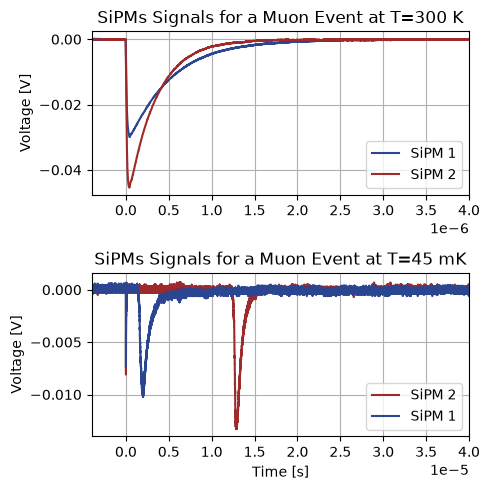

In [5]:
tekfile = "/archive/4sepmdetectshigherupwkndrun/SaveOnEvent_ALL_20260905210639441.csv"
lecfile1 = "/archive/24augrtmuon/24augrtmuon/C1--muon--00000.txt"
lecfile2 = "/archive/24augrtmuon/24augrtmuon/C2--muon--00000.txt"
plot_waveforms(tekfile,lecfile1, lecfile2)

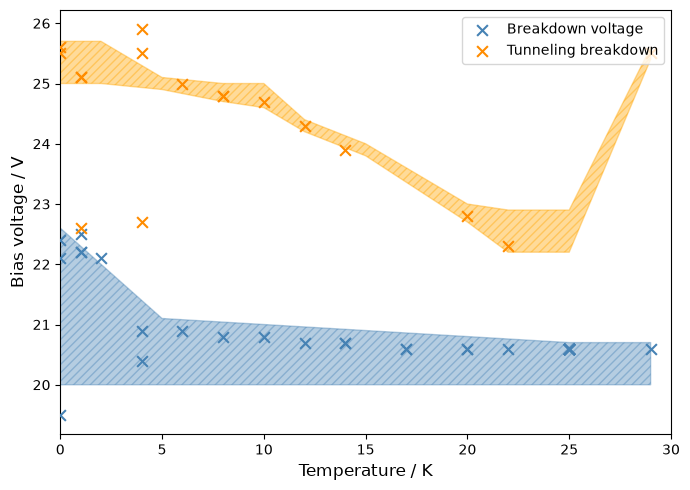

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

# ── DATA (eyeballed from your scatter plot – edit these freely) ──────────────

# Breakdown voltage (blue) – lower cluster ~20.5–21 V
temp_breakdown = np.array([
    0, 0, 0, 1, 1, 1, 2, 4, 4, 6, 8, 10, 12, 14, 14,
    17, 17, 20, 20, 22, 25, 25, 25, 25, 25, 25, 25, 25, 25, 29
])
v_breakdown = np.array([
    19.5, 22.1, 22.4, 22.2, 22.2, 22.5, 22.1, 20.4, 20.9, 20.9, 20.8, 20.8, 20.7, 20.7, 20.7,
    20.6, 20.6, 20.6, 20.6, 20.6, 20.6, 20.6, 20.6, 20.6, 20.6, 20.6, 20.6, 20.6, 20.6, 20.6
])

# Tunneling breakdown (orange) – upper cluster ~22–26 V
temp_tunneling = np.array([
    0, 0, 1, 1, 1, 4, 4, 4, 6, 8, 8, 10, 12, 14, 20, 22, 29
])
v_tunneling = np.array([
    25.5, 25.6, 25.1, 25.1, 22.6, 25.9, 25.5, 22.7, 25.0, 24.8, 24.8, 24.7, 24.3, 23.9, 22.8, 22.3, 25.5
])

# ── SHADED REGIONS ────────────────────────────────────────────────────────────
# For each cluster, define (temp, v_lower, v_upper) to shade between.
# These are the band boundaries – adjust to taste.

# Blue band: tight strip around breakdown voltage
temp_blue = np.array([0, 5, 10, 15, 20, 25, 29])
v_blue_lower = np.array([20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0])
v_blue_upper = np.array([22.6, 21.1, 21.0, 20.9, 20.8, 20.7, 20.7])

# Orange band: upper region
temp_orange = np.array([0,  2,   5,   8,  10,  12,  15,  20,  22,  25,  29])
v_orange_lower = np.array([25.0, 25.0, 24.9, 24.7, 24.6, 24.2, 23.8, 22.7, 22.2, 22.2, 25.4])
v_orange_upper = np.array([25.7, 25.7, 25.1, 25.0, 25.0, 24.4, 24.0, 23.0, 22.9, 22.9, 25.6])

# ── PLOT ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

# Shaded bands with hatching
ax.fill_between(temp_blue, v_blue_lower, v_blue_upper,
                color='steelblue', alpha=0.4, hatch='////', label=None)

ax.fill_between(temp_orange, v_orange_lower, v_orange_upper,
                color='orange', alpha=0.4, hatch='////', label=None)

# Scatter markers
ax.scatter(temp_breakdown, v_breakdown, marker='x', color='steelblue',
           s=60, linewidths=1.5, label='Breakdown voltage', zorder=5)
ax.scatter(temp_tunneling, v_tunneling, marker='x', color='darkorange',
           s=60, linewidths=1.5, label='Tunneling breakdown', zorder=5)

# Labels & formatting
ax.set_xlabel('Temperature / K', fontsize=12)
ax.set_ylabel('Bias voltage / V', fontsize=12)
ax.set_xlim(0, 30)
ax.legend(loc='upper right', fontsize=10)
ax.grid(False)

plt.tight_layout()
plt.savefig('sipm_breakdown.png', dpi=150)
plt.show()